# Push-v3 PPO Split Results Notebook


In [1]:
from pathlib import Path
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

ROOT = Path('push_v3_ppo_split_runs')
RESULTS = ROOT / 'results'
AGG_PATH = RESULTS / 'push_v3_aggregate_results.csv'
EP_PATH = RESULTS / 'push_v3_per_episode_results.csv'

# Για re-evaluation results, κάνε uncomment αυτά:
# AGG_PATH = RESULTS / 'eval_final_models' / 'push_v3_eval_summary_by_run.csv'
# EP_PATH = RESULTS / 'eval_final_models' / 'push_v3_eval_raw_episodes.csv'

print('Aggregate:', AGG_PATH)
print('Per episode:', EP_PATH)
agg = pd.read_csv(AGG_PATH)
episodes = pd.read_csv(EP_PATH) if EP_PATH.exists() else None
print('Aggregate shape:', agg.shape)
print('Per-episode shape:', None if episodes is None else episodes.shape)
display(agg.head())
print(agg.columns.tolist())

Aggregate: push_v3_ppo_split_runs\results\push_v3_aggregate_results.csv
Per episode: push_v3_ppo_split_runs\results\push_v3_per_episode_results.csv
Aggregate shape: (9, 29)
Per-episode shape: (630, 14)


,run_name,env_name,config_name,split_id,split_seed,train_seed,total_timesteps,n_envs,rollout_size,vecnormalize,...,test_avg_return,test_std_return,test_avg_steps,test_avg_first_success_step,test_episodes,success_gap,return_gap,model_path,vecnormalize_path,tensorboard_dir
0,ppo_push-v3_base_push_split0_splitseed67_train...,push-v3,base_push,0,67,11,6000000,4,4096,True,...,153.122673,15.481160,39.8,39.8,25,-0.088889,71.650666,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
1,ppo_push-v3_base_push_split1_splitseed68_train...,push-v3,base_push,1,68,11,6000000,4,4096,True,...,568.506382,795.025677,135.6,44.5,25,-0.088889,-282.253764,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
2,ppo_push-v3_base_push_split2_splitseed75_train...,push-v3,base_push,2,75,11,6000000,4,4096,True,...,159.557606,23.022184,36.8,36.8,25,-0.111111,115.851027,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
3,ppo_push-v3_careful_push_split0_splitseed67_tr...,push-v3,careful_push,0,67,11,6000000,4,4096,True,...,159.836447,28.207887,37.0,37.0,25,-0.022222,19.069368,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\tensorboard
4,ppo_push-v3_careful_push_split1_splitseed68_tr...,push-v3,careful_push,1,68,11,6000000,4,4096,True,...,164.828872,25.343901,37.8,37.8,25,0.000000,7.677837,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\tensorboard


['run_name', 'env_name', 'config_name', 'split_id', 'split_seed', 'train_seed', 'total_timesteps', 'n_envs', 'rollout_size', 'vecnormalize', 'train_idx', 'test_idx', 'train_success_rate', 'train_avg_return', 'train_std_return', 'train_avg_steps', 'train_avg_first_success_step', 'train_episodes', 'test_success_rate', 'test_avg_return', 'test_std_return', 'test_avg_steps', 'test_avg_first_success_step', 'test_episodes', 'success_gap', 'return_gap', 'model_path', 'vecnormalize_path', 'tensorboard_dir']


## Normalize column names

Το training CSV και το re-evaluation CSV έχουν λίγο διαφορετικά column names. Αυτό το cell τα ενώνει σε κοινή μορφή.

In [2]:
df = agg.copy()

# If using eval script summary, convert long group format to wide train/test format.
if 'group' in df.columns and 'success_rate' in df.columns:
    id_cols = ['config_name', 'split_id', 'split_seed', 'train_seed', 'total_timesteps']
    optional = ['run_name', 'model_path', 'vecnormalize_path']
    id_cols = [c for c in id_cols + optional if c in df.columns]
    wide = df.pivot_table(index=id_cols, columns='group', values=['success_rate', 'avg_return', 'avg_first_success_step'], aggfunc='first')
    wide.columns = [f'{group}_{metric}' for metric, group in wide.columns]
    df = wide.reset_index()

rename_map = {
    'train_success_rate': 'train_success',
    'test_success_rate': 'test_success',
    'train_avg_return': 'train_return',
    'test_avg_return': 'test_return',
    'train_avg_first_success_step': 'train_first_success_step',
    'test_avg_first_success_step': 'test_first_success_step',
}
df = df.rename(columns=rename_map)

if 'success_gap' not in df.columns and {'train_success', 'test_success'} <= set(df.columns):
    df['success_gap'] = df['train_success'] - df['test_success']
if 'return_gap' not in df.columns and {'train_return', 'test_return'} <= set(df.columns):
    df['return_gap'] = df['train_return'] - df['test_return']

display(df.head())
print(df.columns.tolist())

,run_name,env_name,config_name,split_id,split_seed,train_seed,total_timesteps,n_envs,rollout_size,vecnormalize,...,test_return,test_std_return,test_avg_steps,test_first_success_step,test_episodes,success_gap,return_gap,model_path,vecnormalize_path,tensorboard_dir
0,ppo_push-v3_base_push_split0_splitseed67_train...,push-v3,base_push,0,67,11,6000000,4,4096,True,...,153.122673,15.481160,39.8,39.8,25,-0.088889,71.650666,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
1,ppo_push-v3_base_push_split1_splitseed68_train...,push-v3,base_push,1,68,11,6000000,4,4096,True,...,568.506382,795.025677,135.6,44.5,25,-0.088889,-282.253764,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
2,ppo_push-v3_base_push_split2_splitseed75_train...,push-v3,base_push,2,75,11,6000000,4,4096,True,...,159.557606,23.022184,36.8,36.8,25,-0.111111,115.851027,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\models\ppo_push-v3_base...,push_v3_ppo_split_runs\tensorboard
3,ppo_push-v3_careful_push_split0_splitseed67_tr...,push-v3,careful_push,0,67,11,6000000,4,4096,True,...,159.836447,28.207887,37.0,37.0,25,-0.022222,19.069368,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\tensorboard
4,ppo_push-v3_careful_push_split1_splitseed68_tr...,push-v3,careful_push,1,68,11,6000000,4,4096,True,...,164.828872,25.343901,37.8,37.8,25,0.000000,7.677837,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\models\ppo_push-v3_care...,push_v3_ppo_split_runs\tensorboard


['run_name', 'env_name', 'config_name', 'split_id', 'split_seed', 'train_seed', 'total_timesteps', 'n_envs', 'rollout_size', 'vecnormalize', 'train_idx', 'test_idx', 'train_success', 'train_return', 'train_std_return', 'train_avg_steps', 'train_first_success_step', 'train_episodes', 'test_success', 'test_return', 'test_std_return', 'test_avg_steps', 'test_first_success_step', 'test_episodes', 'success_gap', 'return_gap', 'model_path', 'vecnormalize_path', 'tensorboard_dir']


## Experiment overview

In [3]:
print('Configs:', sorted(df['config_name'].unique()))
print('Splits:', sorted(df['split_id'].unique()))
print('Split seeds:', sorted(df['split_seed'].unique()))
print('Train seeds:', sorted(df['train_seed'].unique()) if 'train_seed' in df.columns else 'N/A')
print('Timesteps:', sorted(df['total_timesteps'].unique()))
print('Rows:', len(df))
cols = ['config_name', 'split_id', 'split_seed', 'train_seed', 'train_success', 'test_success', 'success_gap', 'train_return', 'test_return']
display(df[[c for c in cols if c in df.columns]].sort_values(['config_name', 'split_id']))

Configs: ['base_push', 'careful_push', 'short_rollout_push']
Splits: [np.int64(0), np.int64(1), np.int64(2)]
Split seeds: [np.int64(67), np.int64(68), np.int64(75)]
Train seeds: [np.int64(11)]
Timesteps: [np.int64(6000000)]
Rows: 9


,config_name,split_id,split_seed,train_seed,train_success,test_success,success_gap,train_return,test_return
0,base_push,0,67,11,0.911111,1.0,-0.088889,224.773339,153.122673
1,base_push,1,68,11,0.711111,0.8,-0.088889,286.252618,568.506382
2,base_push,2,75,11,0.888889,1.0,-0.111111,275.408632,159.557606
3,careful_push,0,67,11,0.977778,1.0,-0.022222,178.905816,159.836447
4,careful_push,1,68,11,1.000000,1.0,0.000000,172.506709,164.828872
5,careful_push,2,75,11,0.977778,1.0,-0.022222,173.349034,149.487945
6,short_rollout_push,0,67,11,0.488889,0.8,-0.311111,205.182871,168.879268
7,short_rollout_push,1,68,11,0.466667,0.4,0.066667,1031.600276,231.725810
8,short_rollout_push,2,75,11,0.466667,0.4,0.066667,175.520257,116.257526


## Train vs test success by config/split

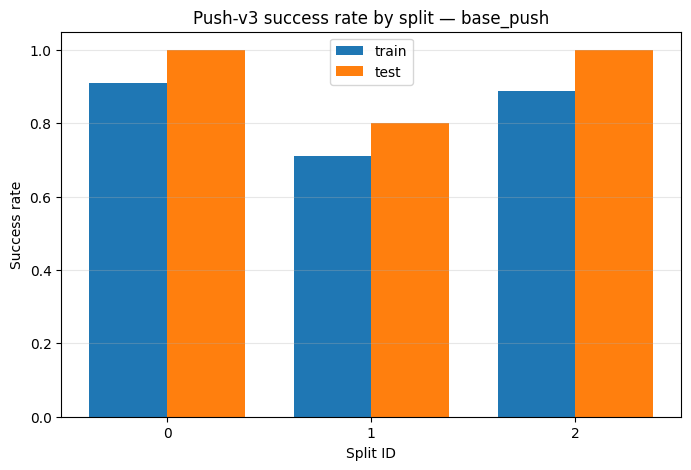

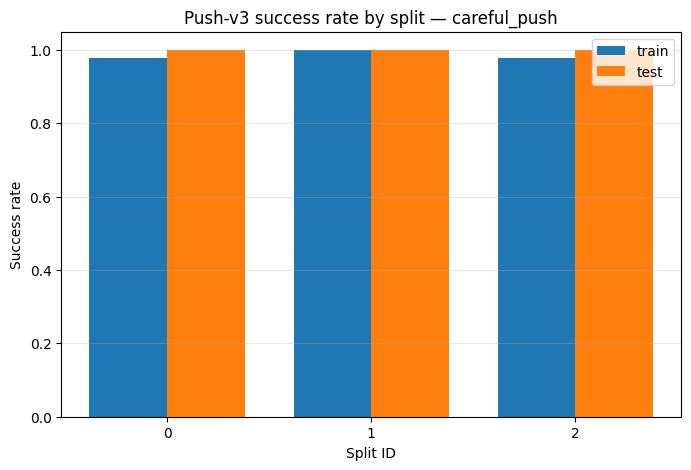

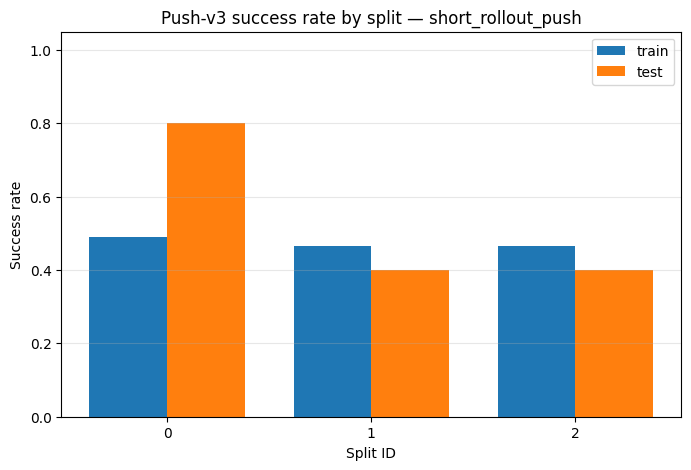

In [4]:
for config in sorted(df['config_name'].unique()):
    d = df[df['config_name'] == config].sort_values('split_id')
    x = np.arange(len(d))
    width = 0.38
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, d['train_success'], width, label='train')
    ax.bar(x + width/2, d['test_success'], width, label='test')
    ax.set_title(f'Push-v3 success rate by split — {config}')
    ax.set_xlabel('Split ID')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(d['split_id'])
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.show()

## 4. Mean success across splits

,config_name,train_success_mean,train_success_std,test_success_mean,test_success_std,train_return_mean,test_return_mean,success_gap_mean,success_gap_std,runs
0,base_push,0.837037,0.10962,0.933333,0.11547,262.144863,293.728887,-0.096296,0.01283,3
1,careful_push,0.985185,0.01283,1.000000,0.00000,174.920519,158.051088,-0.014815,0.01283,3
2,short_rollout_push,0.474074,0.01283,0.533333,0.23094,470.767801,172.287535,-0.059259,0.21811,3


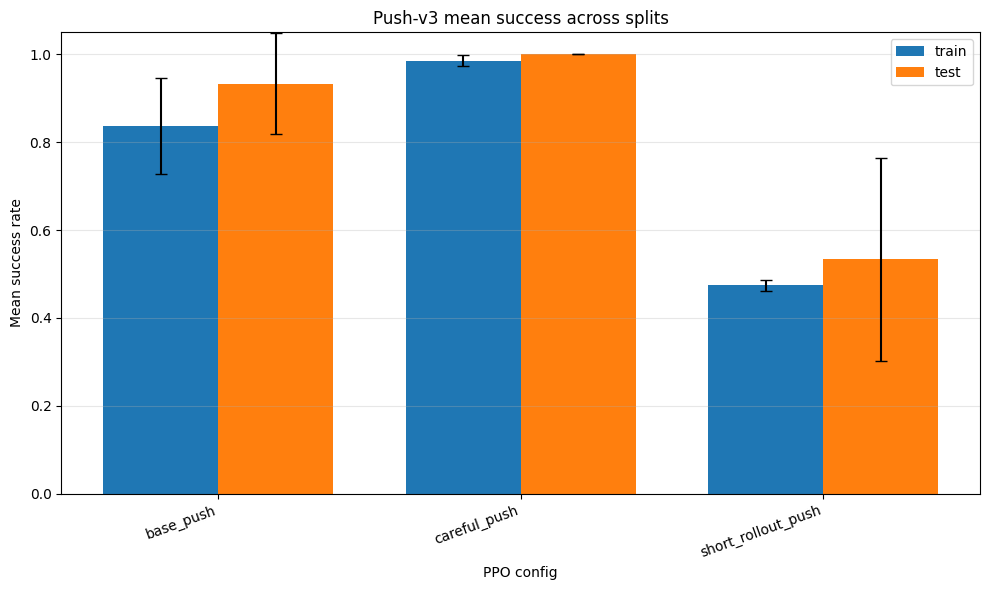

In [5]:
summary = (
    df.groupby('config_name')
    .agg(
        train_success_mean=('train_success', 'mean'),
        train_success_std=('train_success', 'std'),
        test_success_mean=('test_success', 'mean'),
        test_success_std=('test_success', 'std'),
        train_return_mean=('train_return', 'mean'),
        test_return_mean=('test_return', 'mean'),
        success_gap_mean=('success_gap', 'mean'),
        success_gap_std=('success_gap', 'std'),
        runs=('split_id', 'count'),
    )
    .reset_index()
)
display(summary)

x = np.arange(len(summary))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, summary['train_success_mean'], width, yerr=summary['train_success_std'].fillna(0), capsize=4, label='train')
ax.bar(x + width/2, summary['test_success_mean'], width, yerr=summary['test_success_std'].fillna(0), capsize=4, label='test')
ax.set_title('Push-v3 mean success across splits')
ax.set_xlabel('PPO config')
ax.set_ylabel('Mean success rate')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary['config_name'], rotation=20, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Success gap: train - test

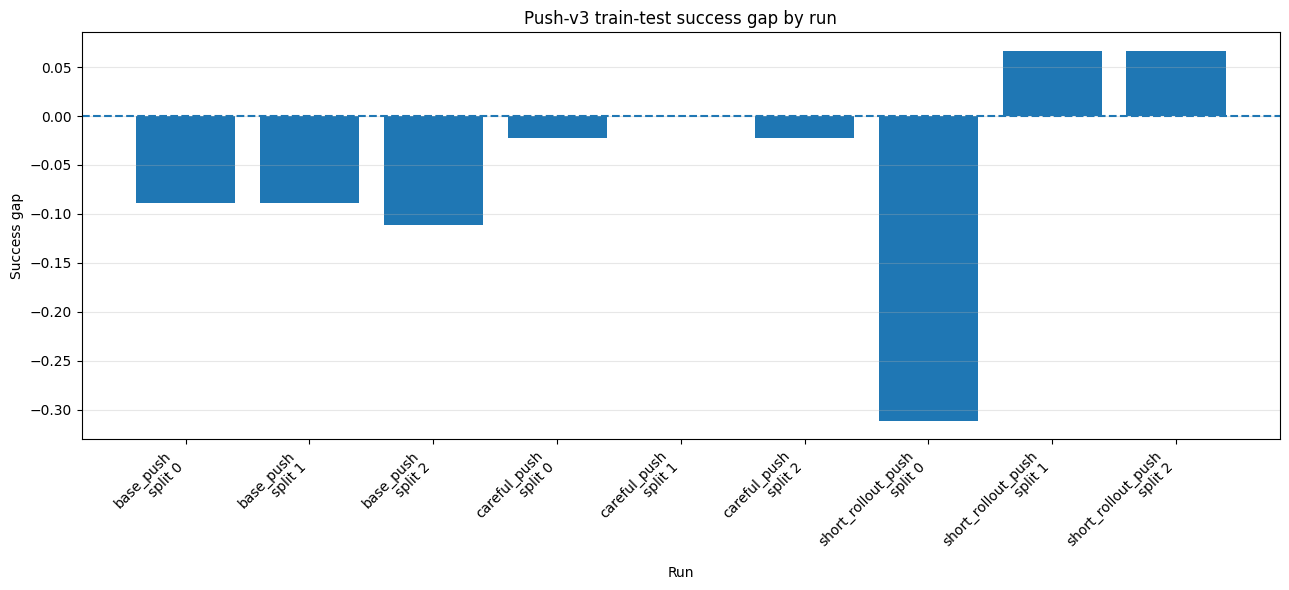

,config_name,split_id,train_success,test_success,success_gap
0,base_push,0,0.911111,1.0,-0.088889
1,base_push,1,0.711111,0.8,-0.088889
2,base_push,2,0.888889,1.0,-0.111111
3,careful_push,0,0.977778,1.0,-0.022222
4,careful_push,1,1.000000,1.0,0.000000
5,careful_push,2,0.977778,1.0,-0.022222
6,short_rollout_push,0,0.488889,0.8,-0.311111
7,short_rollout_push,1,0.466667,0.4,0.066667
8,short_rollout_push,2,0.466667,0.4,0.066667


In [6]:
plot_df = df.sort_values(['config_name', 'split_id']).reset_index(drop=True)
labels = plot_df['config_name'] + '\nsplit ' + plot_df['split_id'].astype(str)
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x, plot_df['success_gap'])
ax.axhline(0, linestyle='--')
ax.set_title('Push-v3 train-test success gap by run')
ax.set_xlabel('Run')
ax.set_ylabel('Success gap')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
display(plot_df[['config_name', 'split_id', 'train_success', 'test_success', 'success_gap']])

## First success step

Lower is better

,config_name,train_first_success_step_mean,test_first_success_step_mean
0,base_push,49.931504,40.366667
1,careful_push,38.084007,36.533333
2,short_rollout_push,77.339827,55.500000


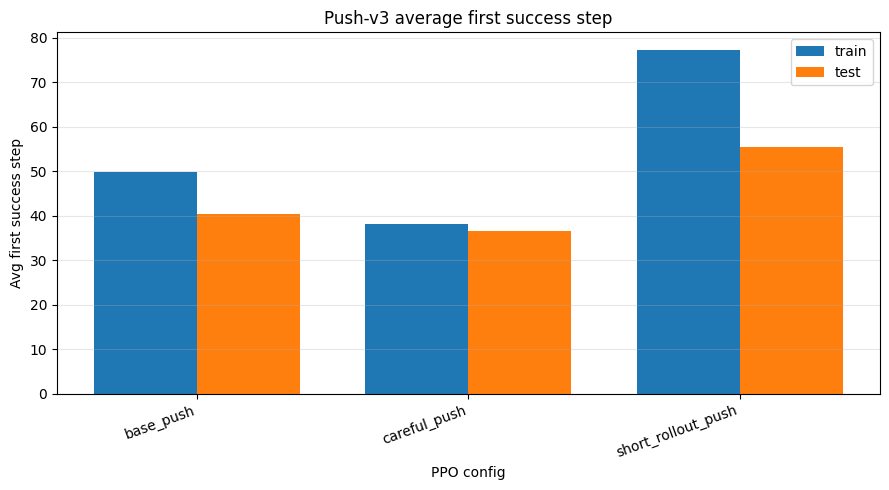

In [7]:
first_cols = {'train_first_success_step', 'test_first_success_step'}
if first_cols <= set(df.columns):
    fs_summary = df.groupby('config_name').agg(
        train_first_success_step_mean=('train_first_success_step', 'mean'),
        test_first_success_step_mean=('test_first_success_step', 'mean'),
    ).reset_index()
    display(fs_summary)
    x = np.arange(len(fs_summary))
    width = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, fs_summary['train_first_success_step_mean'], width, label='train')
    ax.bar(x + width/2, fs_summary['test_first_success_step_mean'], width, label='test')
    ax.set_title('Push-v3 average first success step')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Avg first success step')
    ax.set_xticks(x)
    ax.set_xticklabels(fs_summary['config_name'], rotation=20, ha='right')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('First-success columns not found in this CSV.')

## Per-episode distributions

In [8]:
if episodes is not None:
    display(episodes.head())
    print(episodes.columns.tolist())
    config_col = 'config_name' if 'config_name' in episodes.columns else 'config'
    ep_summary = episodes.groupby([config_col, 'split_id', 'group'])['success'].mean().reset_index()
    display(ep_summary.head(30))
else:
    print('No per-episode CSV found.')

,config,split_id,split_seed,group,task_local_idx,episode,success,return,steps,first_success_step,run_name,train_seed,total_timesteps,model_path
0,base_push,0,67,train,0,0,1.0,155.503862,39,39.0,ppo_push-v3_base_push_split0_splitseed67_train...,11,6000000,push_v3_ppo_split_runs\models\ppo_push-v3_base...
1,base_push,0,67,train,1,0,1.0,141.218954,37,37.0,ppo_push-v3_base_push_split0_splitseed67_train...,11,6000000,push_v3_ppo_split_runs\models\ppo_push-v3_base...
2,base_push,0,67,train,2,0,1.0,192.783565,45,45.0,ppo_push-v3_base_push_split0_splitseed67_train...,11,6000000,push_v3_ppo_split_runs\models\ppo_push-v3_base...
3,base_push,0,67,train,3,0,1.0,226.422079,52,52.0,ppo_push-v3_base_push_split0_splitseed67_train...,11,6000000,push_v3_ppo_split_runs\models\ppo_push-v3_base...
4,base_push,0,67,train,4,0,1.0,153.205696,39,39.0,ppo_push-v3_base_push_split0_splitseed67_train...,11,6000000,push_v3_ppo_split_runs\models\ppo_push-v3_base...


['config', 'split_id', 'split_seed', 'group', 'task_local_idx', 'episode', 'success', 'return', 'steps', 'first_success_step', 'run_name', 'train_seed', 'total_timesteps', 'model_path']


,config,split_id,group,success
0,base_push,0,test,1.000000
1,base_push,0,train,0.911111
2,base_push,1,test,0.800000
3,base_push,1,train,0.711111
4,base_push,2,test,1.000000
5,base_push,2,train,0.888889
6,careful_push,0,test,1.000000
7,careful_push,0,train,0.977778
8,careful_push,1,test,1.000000
9,careful_push,1,train,1.000000


## Save figures

In [9]:
fig_dir = ROOT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary))
width = 0.38
ax.bar(x - width/2, summary['train_success_mean'], width, yerr=summary['train_success_std'].fillna(0), capsize=4, label='train')
ax.bar(x + width/2, summary['test_success_mean'], width, yerr=summary['test_success_std'].fillna(0), capsize=4, label='test')
ax.set_title('Push-v3 mean success across splits')
ax.set_xlabel('PPO config')
ax.set_ylabel('Mean success rate')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary['config_name'], rotation=20, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
out1 = fig_dir / 'push_v3_mean_success_across_splits.png'
fig.savefig(out1, dpi=200, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(plot_df))
ax.bar(x, plot_df['success_gap'])
ax.axhline(0, linestyle='--')
ax.set_title('Push-v3 train-test success gap by run')
ax.set_xlabel('Run')
ax.set_ylabel('Success gap')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out2 = fig_dir / 'push_v3_success_gap_by_run.png'
fig.savefig(out2, dpi=200, bbox_inches='tight')
plt.close(fig)
print('Saved:')
print(out1)
print(out2)

Saved:
push_v3_ppo_split_runs\figures\push_v3_mean_success_across_splits.png
push_v3_ppo_split_runs\figures\push_v3_success_gap_by_run.png
